<a href="https://colab.research.google.com/github/fboldt/aulasml/blob/master/aula11a_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Principal Component Analisys

In [45]:
from sklearn.datasets import load_breast_cancer
X, y = load_breast_cancer(return_X_y=True)
print(X.shape, len(set(y)))

(569, 30) 2


In [46]:
30*29

870

In [47]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X)

# Extract eigenvectors and eigenvalues
eigenvectors = pca.components_
eigenvalues = pca.explained_variance_

print("Eigenvectors shape:", eigenvectors.shape)
print("Eigenvalues:", eigenvalues)

Eigenvectors shape: (30, 30)
Eigenvalues: [4.43782605e+05 7.31010006e+03 7.03833742e+02 5.46487379e+01
 3.98900178e+01 3.00458768e+00 1.81533029e+00 3.71466740e-01
 1.55513547e-01 8.40612196e-02 3.16089532e-02 7.49736506e-03
 3.16165651e-03 2.16150395e-03 1.32653879e-03 6.40269301e-04
 3.74883320e-04 2.35169625e-04 1.84583467e-04 1.64180063e-04
 7.81102006e-05 5.76111659e-05 3.49172775e-05 2.83952688e-05
 1.61463676e-05 1.24902419e-05 3.68048171e-06 2.84790425e-06
 2.00491564e-06 7.01997261e-07]


In [48]:
X_pca = pca.transform(X)
print(X_pca.shape)

(569, 30)


In [49]:
print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))

[9.82044672e-01 1.61764899e-02 1.55751075e-03 1.20931964e-04
 8.82724536e-05 6.64883951e-06 4.01713682e-06 8.22017197e-07
 3.44135279e-07 1.86018721e-07 6.99473205e-08 1.65908878e-08
 6.99641648e-09 4.78318305e-09 2.93549213e-09 1.41684926e-09
 8.29577731e-10 5.20405880e-10 4.08463983e-10 3.63313376e-10
 1.72849736e-10 1.27487508e-10 7.72682973e-11 6.28357715e-11
 3.57302295e-11 2.76396041e-11 8.14452259e-12 6.30211541e-12
 4.43666944e-12 1.55344680e-12]
0.9999999999999996


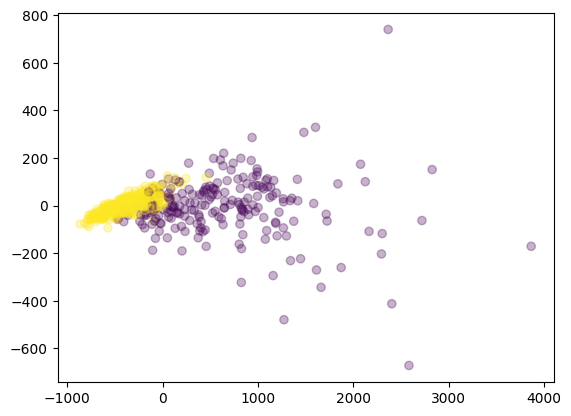

In [50]:
import matplotlib.pyplot as plt
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, alpha=0.3)
plt.show()

In [51]:
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import cross_validate

model = RidgeClassifier()

scores = cross_validate(model, X, y)
print(scores['test_score'])
print(scores['test_score'].mean())
print()

n_feats = 16

scores = cross_validate(model, X_pca[:,:n_feats], y)
print(scores['test_score'])
print(scores['test_score'].mean())
print()

scores = cross_validate(model, X[:,:n_feats], y)
print(scores['test_score'])
print(scores['test_score'].mean())
print()

[0.92105263 0.94736842 0.96491228 0.95614035 0.98230088]
0.9543549138332557

[0.92105263 0.94736842 0.96491228 0.95614035 0.98230088]
0.9543549138332557

[0.89473684 0.90350877 0.93859649 0.94736842 0.94690265]
0.9262226362366093



#PCA Drawbacks

(100, 2) 2


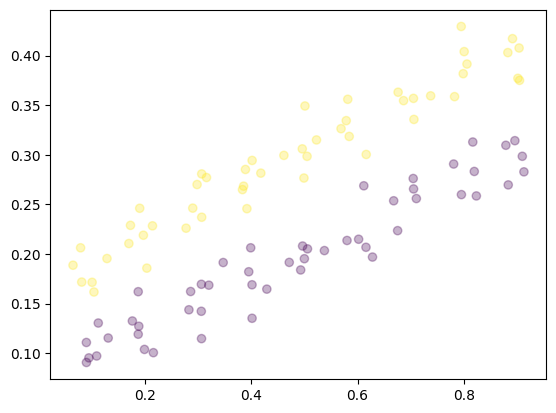

In [52]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=100,
                  centers=[[0.1, 0.100], [0.1, 0.200],
                           [0.2, 0.125], [0.2, 0.225],
                           [0.3, 0.150], [0.3, 0.250],
                           [0.4, 0.175], [0.4, 0.275],
                           [0.5, 0.200], [0.5, 0.300],
                           [0.6, 0.225], [0.6, 0.325],
                           [0.7, 0.250], [0.7, 0.350],
                           [0.8, 0.275], [0.8, 0.375],
                           [0.9, 0.300], [0.9, 0.400]],
                  n_features=2,
                  cluster_std=0.02,
                  random_state=42)

y = y % 2
print(X.shape, len(set(y)))

plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.3)
plt.show()

In [53]:
scores = cross_validate(model, X, y)
print(scores['test_score'])
print(scores['test_score'].mean())
print()

[1. 1. 1. 1. 1.]
1.0



In [54]:
model.fit(X, y)
y_pred = model.predict(X)

model.coef_, model.intercept_


(array([-0.85895002,  3.73630172]), array([-0.50762554]))

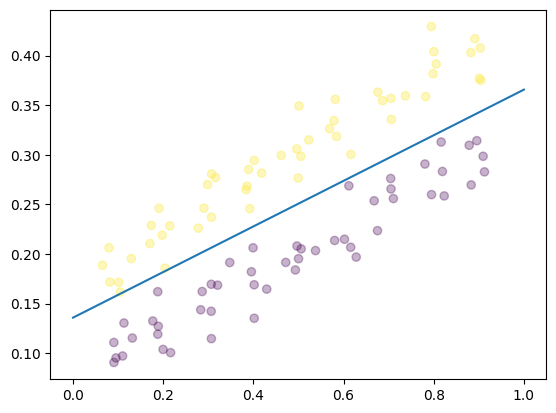

In [55]:
import numpy as np

def plot_hyperplan(coefs, intercept, xs = [0, 1]):
  xs = np.array(xs)
  ys = -(coefs[0] * xs + intercept) / coefs[1]
  plt.plot(xs, ys)

plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.3)
plot_hyperplan(model.coef_, model.intercept_)
plt.show()

[0.96210863 0.03789137]


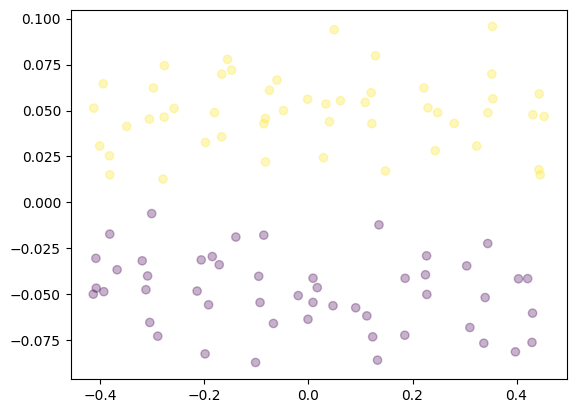

In [56]:
pca = PCA()
X_pca = pca.fit_transform(X)
print(pca.explained_variance_ratio_)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, alpha=0.3)
plt.show()

In [57]:
model = RidgeClassifier()

scores = cross_validate(model, X, y)
print(scores['test_score'])
print(scores['test_score'].mean())
print()

n_feats = 1

scores = cross_validate(model, X_pca[:,:n_feats], y)
print(scores['test_score'])
print(scores['test_score'].mean())
print()

scores = cross_validate(model, X[:,:n_feats], y)
print(scores['test_score'])
print(scores['test_score'].mean())
print()

[1. 1. 1. 1. 1.]
1.0

[0.55 0.5  0.45 0.45 0.6 ]
0.51

[0.5  0.5  0.45 0.4  0.45]
0.4600000000000001



#PCA advantages

(100, 2) 2


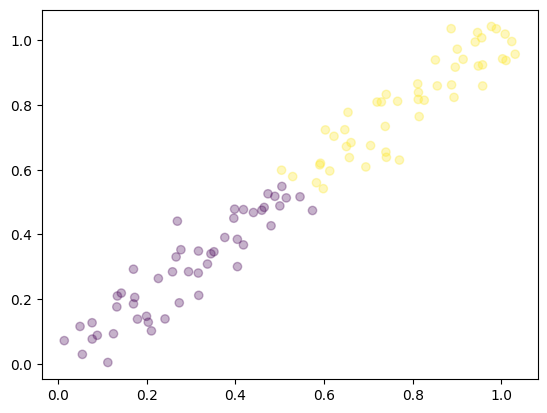

In [61]:
X, y = make_blobs(n_samples=100,
                  centers=[[0.1, 0.1],
                           [0.2, 0.2],
                           [0.3, 0.3],
                           [0.4, 0.4],
                           [0.5, 0.5],
                           [0.6, 0.6],
                           [0.7, 0.7],
                           [0.8, 0.8],
                           [0.9, 0.9],
                           [1.0, 1.0]],
                  n_features=2,
                  cluster_std=0.05,
                  random_state=42)

y = y > 4
print(X.shape, len(set(y)))

plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.3)
plt.show()

[0.98812557 0.01187443]


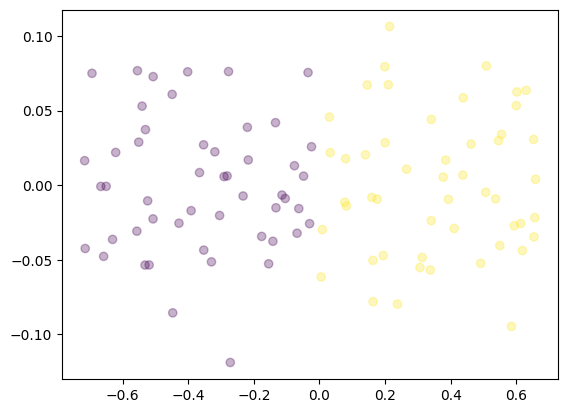

In [62]:
pca = PCA()
X_pca = pca.fit_transform(X)
print(pca.explained_variance_ratio_)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, alpha=0.3)
plt.show()

In [63]:
model = RidgeClassifier()

scores = cross_validate(model, X, y)
print(scores['test_score'])
print(scores['test_score'].mean())
print()

n_feats = 1

scores = cross_validate(model, X_pca[:,:n_feats], y)
print(scores['test_score'])
print(scores['test_score'].mean())
print()

scores = cross_validate(model, X[:,:n_feats], y)
print(scores['test_score'])
print(scores['test_score'].mean())
print()

[1. 1. 1. 1. 1.]
1.0

[1. 1. 1. 1. 1.]
1.0

[0.95 1.   0.95 1.   0.9 ]
0.96

